# Comparaison de modèles de prévision de la demande pour la supply chain (classification)

## Introduction

Après avoir tenté de prédire les volumes de ventes avec la régression, nous voulions tenter la classification. Elle pourrait être plus pertinente et plus adapté pour aider Sophie Martin. Nous pourrions ainsi identifier directement les périodes à risque de rupture.

Nous avons commencé ici par une classification manuelle avec toutes nos données (par produit), puis nous nous sommes rendu compte que les distributions étaient trop déséquilibrées pour donner de bons résultats donc nous avons étudié les quantiles pour découper nos ventes. La deuxième partie reprend finalement le preprocessing et feature engineering du notebook régression, donc nous parlons de nombre de ventes par jour. C'est aussi pour cela qu'on compte beaucoup moins de données.

---

## Classification manuelle

### Préparation des données

In [23]:
import pandas as pd
import numpy as np

# Chargement des données
sales = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")
calendar = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/calendar.csv")

# Transformation des colonnes en lignes
sales = sales.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d",
    value_name="sales"
)

# Merge avec calendrier pour ajouter les dates
data = sales.merge(calendar, on="d", how="left")

# Dates
data["date"] = pd.to_datetime(data["date"])
data["dayofweek"] = data["date"].dt.dayofweek
data["month"] = data["date"].dt.month

# Tri par produits et dates
data = data.sort_values(["id", "date"])

# Lags (pour les séries temporelles)
data["lag_1"] = data.groupby("id")["sales"].shift(1) # Les ventes d'hier
data["lag_7"] = data.groupby("id")["sales"].shift(7) # Les ventes d'il y a une semaine
data["lag_28"] = data.groupby("id")["sales"].shift(28) # Les ventes du mois dernier

# Moyenne mobile des 7 derniers jours
data["rolling_mean_7"] = (data.groupby("id")["sales"].transform(lambda x: x.shift(1).rolling(7).mean()))

# Premier jour sans passé donc il faut le supprimer
data = data.dropna()

# On vérifie qu'il y a assez de données
print(data.shape)

(121960, 26)


### En 3 classes (Random Forest)

In [24]:
def categoriser(x):
    if x == 0:
        return "faible"
    elif x < 5:
        return "moyen"
    else:
        return "fort"

data["classe"] = data["sales"].apply(categoriser)

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["classe_encoded"] = le.fit_transform(data["classe"])

In [26]:
split_date = data["date"].max() - pd.Timedelta(days=28)
print(data["date"].min(), data["date"].max())

train = data[data["date"] <= split_date]
test = data[data["date"] > split_date]
print(data["date"].min(), data["date"].max())

features = ["dayofweek", "month", "lag_1", "lag_7", "lag_28", "rolling_mean_7"]

X_train = train[features]
y_train = train["classe_encoded"]

X_test = test[features]
y_test = test["classe_encoded"]

2011-04-24 00:00:00 2014-06-15 00:00:00
2011-04-24 00:00:00 2014-06-15 00:00:00


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import recall_score, f1_score

clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# Sauvegarde des scores pour le tableau recap
acc_manuel_3 = accuracy_score(y_test, pred)
recall_manuel_3 = recall_score(y_test, pred, average=None)[le.transform(["fort"])[0]]
f1_manuel_3 = f1_score(y_test, pred, average="macro")

Accuracy : 0.7273204329288291
              precision    recall  f1-score   support

           0       0.81      0.85      0.83     19345
           1       0.58      0.63      0.60      2234
           2       0.56      0.48      0.52      8911

    accuracy                           0.73     30490
   macro avg       0.65      0.65      0.65     30490
weighted avg       0.72      0.73      0.72     30490



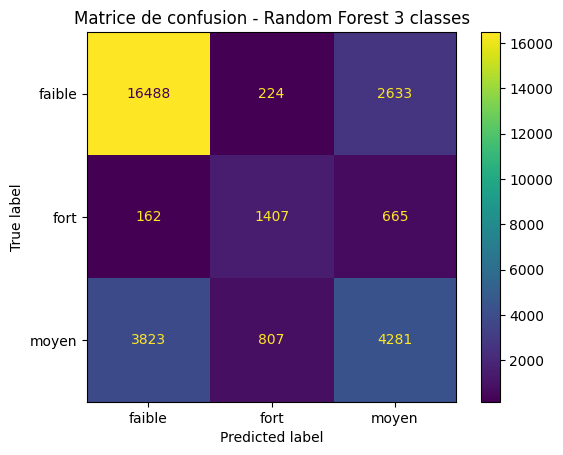

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, pred,
    display_labels=le.classes_)

plt.title("Matrice de confusion - Random Forest 3 classes")
plt.show()

Le Random Forest en 3 classes sans balance prédit correctement environ 3 cas sur 4, ce qui est plutot bon.

Cependant, ces résultats sont assez mal réparti entre classes : les périodes de faibles demande sont très bien identifiées (aussi parce que c'est la classe majoritaire donc le modèle est bien entraîné dessus) mais les pics sont difficiles à détecter. La classe O (faible demande) est la mieux prédite, la classe 1 (moyenne) a des résultats assez moyen et confond souvent avec faible ou forte et la classe 2 (forte demande) rate beaucoup de pics (48% de pics détectés).

La matrice de confusion confirme que la classe 'faible' est très bien identifiée mais que le modèle confond fréquemment 'moyen' avec 'fort' et 'moyen' avec 'faible'. Cela peut peut-être s'expliquer par le faible nombre d'exemples de classe 'moyen' dans les données. Le modèle a donc tendance à confondre la classe vraie avec la classe la plus proche (ex : 'faible' avec 'moyen', 'fort' avec 'moyen' et 'moyen' avec 'faible'), ce qui est plutot positif car cela montre qu'il différencie très bien 'fort' et 'faible'.

### En 3 classes avec une balance

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# Sauvegarde des scores pour le tableau recap
acc_manuel_balance = accuracy_score(y_test, pred)
recall_manuel_balance = recall_score(y_test, pred, average=None)[le.transform(["fort"])[0]]
f1_manuel_balance = f1_score(y_test, pred, average="macro")

Accuracy : 0.6419153820924893
              precision    recall  f1-score   support

           0       0.89      0.60      0.72     19345
           1       0.49      0.64      0.55      2234
           2       0.45      0.73      0.56      8911

    accuracy                           0.64     30490
   macro avg       0.61      0.66      0.61     30490
weighted avg       0.73      0.64      0.66     30490



Le modèle précédent était bon globalement mais mauvais sur les pics. Ici, il est meilleur sur les pics mais moins bon globalement (l'accuracy passe de 73% à 64%).

La classe 2 (pics) passe de 0.48 en recall à 0.73 ce qui est une énorme amélioration : le modèle détecte beaucoup plus de pics. Cependant, la classe 0 (faible) passe de 0.85 à 0.6 ce qui est vraiment moins bon.

### Modèle binaire (détection de périodes normales ou pics) avec seuil >= 5

Nous allons maintenant voir s'il serait intéressant de transformer notre problème en problème binaire. 0 serait une période de vente normal et 1 représenterait un pic. Nous pourrions donc prédire les situations à risque.

Accuracy : 0.9166284027550017
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     28256
           1       0.45      0.60      0.51      2234

    accuracy                           0.92     30490
   macro avg       0.71      0.77      0.73     30490
weighted avg       0.93      0.92      0.92     30490



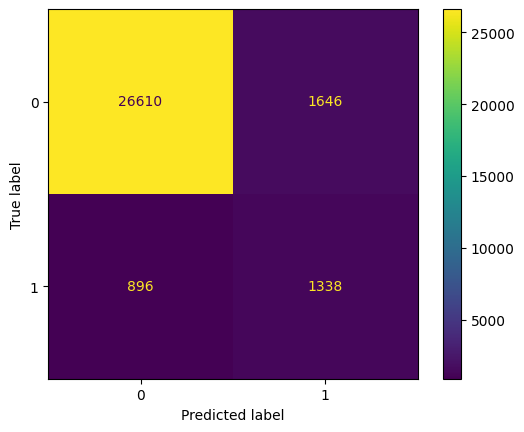

In [31]:
# Définition du pic
data["pic"] = (data["sales"] >= 5).astype(int)

split_date = data["date"].max() - pd.Timedelta(days=28)

train = data[data["date"] <= split_date]
test = data[data["date"] > split_date]

features = ["dayofweek", "month", "lag_1", "lag_7", "lag_28", "rolling_mean_7"]

X_train = train[features]
y_train = train["pic"]

X_test = test[features]
y_test = test["pic"]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

ConfusionMatrixDisplay.from_predictions(y_test, pred)

# Sauvegarde des scores pour le tableau recap
acc_bin_5 = accuracy_score(y_test, pred)
recall_bin_5 = recall_score(y_test, pred, pos_label=1)
f1_bin_5 = f1_score(y_test, pred, average="macro")

Ici, l'accuracy est très bonne (92%) mais trompeuse. Il y a tellement de données de classe 0 que le modèle considère qu'il a bien appris parce qu'il réussit dans 94% des cas à prédire la classe 0, mais lorsqu'on regarde la classe 1, on se rend compte qu'il tombe à 60% de bonne prédiction de pics, ce qui est faible. 

Nous essaierons en modèle suivant d'ajuster le pic pour équilibrer un peu mieux les données.

### Modèle binaire avec seuil >= 2

Accuracy : 0.7660216464414562
              precision    recall  f1-score   support

           0       0.92      0.77      0.84     23872
           1       0.48      0.75      0.58      6618

    accuracy                           0.77     30490
   macro avg       0.70      0.76      0.71     30490
weighted avg       0.82      0.77      0.78     30490



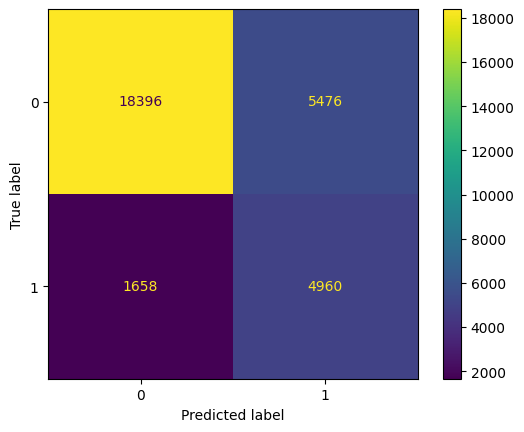

In [32]:
# Définition du pic
data["pic"] = (data["sales"] >= 2).astype(int)

split_date = data["date"].max() - pd.Timedelta(days=28)

train = data[data["date"] <= split_date]
test = data[data["date"] > split_date]

features = ["dayofweek", "month", "lag_1", "lag_7", "lag_28", "rolling_mean_7"]

X_train = train[features]
y_train = train["pic"]

X_test = test[features]
y_test = test["pic"]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

ConfusionMatrixDisplay.from_predictions(y_test, pred)

# Sauvegarde des scores pour le tableau recap
acc_bin_2 = accuracy_score(y_test, pred)
recall_bin_2 = recall_score(y_test, pred, pos_label=1)
f1_bin_2 = f1_score(y_test, pred, average="macro")

La modification du seuil de définition des pics impact fortement les performances du modèle : il détecte à pourcentage quasiment égal les situations de demande élevée et les demandes normales mais l'accuracy globale du modèle baisse forcément en contrepartie.

---

## Classification avec quantiles

Après des recherches, le moyen le plus simple pour assurer un équilibre des classes est l'utilisation de quantiles. C'est donc ce que nous avons tenté, toujours avec une version en 3 classes puis une version binaire. Cette fois ci, nous avons utilisé le nombre de ventes par jour, pour que cela colle avec la régression faite précédement, et soit également moins lourd pour le kernel.

## Préparation des données (identique au notebook régression)

In [33]:
import pandas as pd
import numpy as np

sales = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")
calendar = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/calendar.csv")

sales = sales.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d", value_name="sales")

df = sales.merge(calendar, on="d", how="left")
df["date"] = pd.to_datetime(df["date"])

daily = df.groupby("date")["sales"].sum().reset_index()

daily["dayofweek"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["lag_1"] = daily["sales"].shift(1) 
daily["lag_7"] = daily["sales"].shift(7)
daily["lag_28"] = daily["sales"].shift(28) 
daily["rolling_mean_7"] = daily["sales"].shift(1).rolling(7).mean()
daily["rolling_std_7"]  = daily["sales"].shift(1).rolling(7).std()

daily = daily.dropna()
print(daily.shape)

(1913, 9)


### Création des classes

In [34]:
# Création des 3 classes basées sur les quantiles
# On utilise les quantiles plutôt que des seuils fixes pour que les classes soient équilibrées
q33 = daily["sales"].quantile(0.33)
q67 = daily["sales"].quantile(0.67)

print("Seuil faible/moyen : ", round(q33), "ventes/jour")
print("Seuil moyen/fort : ", round(q67), "ventes/jour")

daily["classe"] = pd.cut(
    daily["sales"],
    bins=[-1, q33, q67, daily["sales"].max()],
    labels=["faible", "moyen", "fort"])

print(daily["classe"].value_counts())

Seuil faible/moyen :  31368 ventes/jour
Seuil moyen/fort :  37117 ventes/jour
classe
moyen     651
faible    631
fort      631
Name: count, dtype: int64


### Visualisation de la distribution des classes

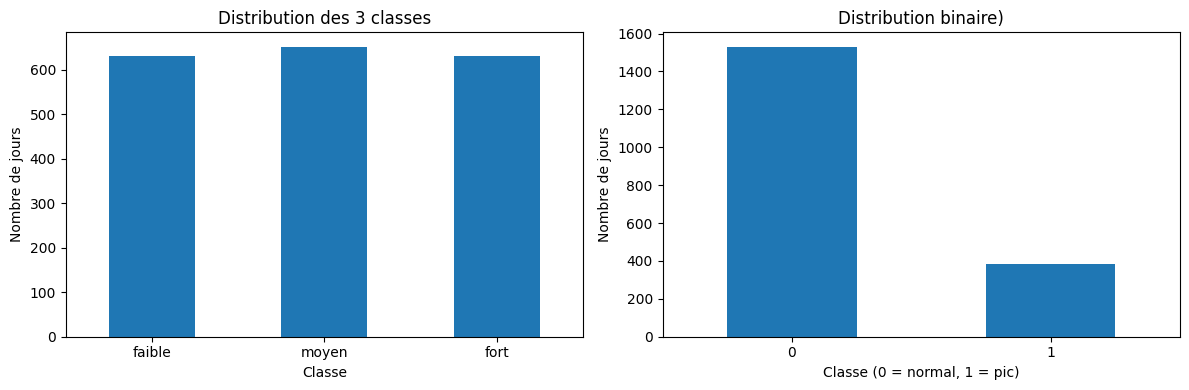

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3 classes
daily["classe"].value_counts().reindex(["faible", "moyen", "fort"]).plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribution des 3 classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre de jours")
axes[0].tick_params(axis="x", rotation=0)

# Binaire
seuil_pic = daily["sales"].quantile(0.80)
daily["pic"] = (daily["sales"] >= seuil_pic).astype(int)
daily["pic"].value_counts().plot(kind="bar", ax=axes[1],)
axes[1].set_title(f"Distribution binaire)")
axes[1].set_xlabel("Classe (0 = normal, 1 = pic)")
axes[1].set_ylabel("Nombre de jours")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Train Test Split

In [36]:
features = [
    "dayofweek", 
    "month",
    "lag_1",
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7"]

split = int(len(daily) * 0.8)
train = daily.iloc[:split]
test  = daily.iloc[split:]

X_train = train[features]
X_test = test[features]

print("Train :", train.shape, "| Test :", test.shape)

Train : (1530, 11) | Test : (383, 11)


On note que le train-test-split est beaucoup plus faible en nombre de données parce que contrairement à la première partie du notebook, nous avons agréger les données. Nous avons maintenant une ligne = un jour = nombre de demandes du jour, sans prendre en compte les produits, les magasins, les events...

---

## Classification 3 classes (Random Forest)

Accuracy : 0.7833
              precision    recall  f1-score   support

      faible       0.70      0.41      0.52        17
        fort       0.95      0.73      0.83       231
       moyen       0.63      0.93      0.75       135

    accuracy                           0.78       383
   macro avg       0.76      0.69      0.70       383
weighted avg       0.83      0.78      0.79       383



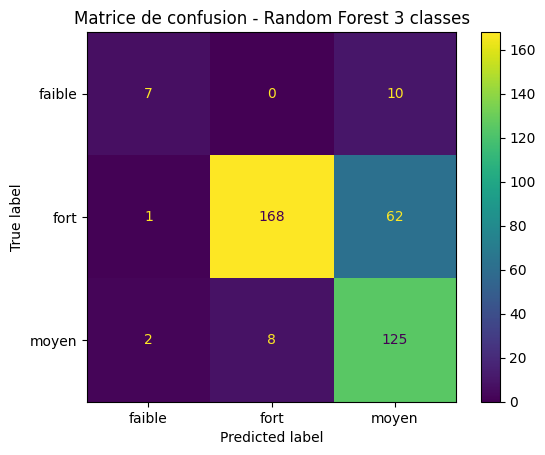

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily["classe_enc"] = le.fit_transform(daily["classe"])

split = int(len(daily) * 0.8)
train = daily.iloc[:split]
test  = daily.iloc[split:]

y_train_3 = train["classe_enc"]
y_test_3 = test["classe_enc"]

clf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_3.fit(X_train, y_train_3)
pred_3 = clf_3.predict(X_test)

# Scores
print("Accuracy :", round(accuracy_score(y_test_3, pred_3), 4))
print(classification_report(y_test_3, pred_3, target_names=le.classes_))

# Matrice de confusion
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test_3, pred_3, display_labels=le.classes_)
plt.title("Matrice de confusion - Random Forest 3 classes")
plt.show()

# Sauvegarde des scores pour le tableau recap
acc_quantile_3 = accuracy_score(y_test_3, pred_3)
recall_quantile_3 = recall_score(y_test_3, pred_3, average=None)[le.transform(["fort"])[0]]
f1_quantile_3 = f1_score(y_test_3, pred_3, average="macro")

Le Random Forest en 3 classes avec quantile a une accuracy meilleure que la version manuelle (on passe de 64% avec la version équilibrée à 78% ici).

Il reste néanmoins un déséquilibre de classe. La classe forte demande est la plus représenté dans les données de test (231 jours) et obtient de bons résultats avec un recall de 0.73. La classe moyenne est bien détectée avec un recall de 0.93 mais elle est parfois confondue avec les classes voisines. Enfin, la classe faible  contient très peu d'exemples (17 jours) ce qui rend son évaluation moins précise. Le modèle différencie donc globalement bien les niveaux de demandes mais confond un peu les classes proches.

Globalement, comme pour la version manuelle, on remarque quand même que les classes voisines sont souvent confondues. Un modèle binaire pourrait peut-être être plus pertinent pour répondre au problème de Sophie Martin qui est plus l'identification de pics.

---

## Transformation en modèle binaire

Nous allons maintenant voir s'il serait plus intéressant ou pas de transformer le problème en problème binaire. 0 représente une période normale et 1 représente un pic. Avec ce modèle, nous pourrions donc prédire si une situations est à risque ou est considérées normales.

Accuracy : 0.8903
              precision    recall  f1-score   support

      Normal       0.87      0.98      0.92       246
         Pic       0.95      0.73      0.83       137

    accuracy                           0.89       383
   macro avg       0.91      0.85      0.87       383
weighted avg       0.90      0.89      0.89       383



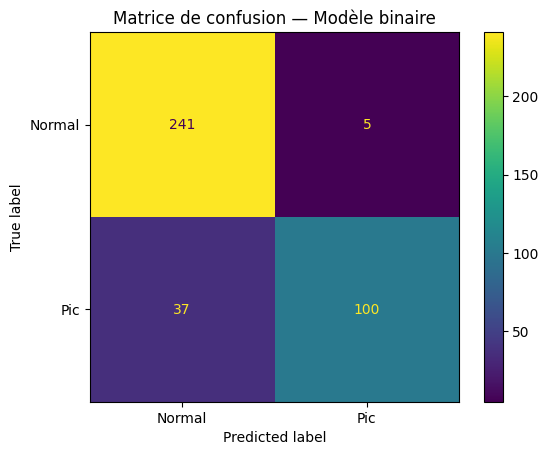

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_binaire = train["pic"]
y_test_binaire = test["pic"]

clf_binaire = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf_binaire.fit(X_train, y_train_binaire)
pred_binaire = clf_binaire.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test_binaire, pred_binaire), 4))
print(classification_report(y_test_binaire, pred_binaire, target_names=["Normal", "Pic"]))

# Matrice de confusion — modèle binaire
ConfusionMatrixDisplay.from_predictions(y_test_binaire, pred_binaire, display_labels=["Normal", "Pic"])

plt.title("Matrice de confusion — Modèle binaire")
plt.show()

# Sauvegarde des scores pour le tableau recap
acc_quantile_bin = accuracy_score(y_test_binaire, pred_binaire)
recall_quantile_bin = recall_score(y_test_binaire, pred_binaire, pos_label=1)
f1_quantile_bin = f1_score(y_test_binaire, pred_binaire, average="macro")

L'accuracy du modèle binaire est très bonne (0.89). On note quand même qu'il y a plus de données de classe 0 donc l'accuracy est très élevée aussi parce que le modèle considère qu'il a bien appris car il réussit dans 98% des cas à prédire la classe 0, mais lorsqu'on regarde la classe 1, on se rend compte qu'il tombe à 73% de bonne prédiction de pics. Les scores sont quand même très bon et ce modèle semble mieux que le précédent pour détecter des pics.

---

## Conclusion

Nous avons comparé plusieurs approches de classification afin de prédire les niveaux de demande et identifier les périodes à risque pour la supply chain. En résumé :

- Manuelle / 3 classes sans balance : accuracy = 0.73, recall fort = 0.48 (mauvais pour les ruptures)
- Manuelle / 3 classes avec balance : accuracy = 0.64, recall fort = 0.73 (meilleur pour anticiper)
- Manuelle / Binaire seuil >= 5 : accuracy = 0.92, recall pic = 0.60 (trop de faux négatifs)
- Manuelle / Binaire seuil >= 2 : accuracy = 0.77, recall pic = 0.75 (meilleur compromis de la version manuelle)
- Quantile / 3 classes : accuracy = 0.78, recall fort = 0.73 (plutôt bon pour les pics et bonne accuracy)
- Quantile / Binaire : accuracy = 0.89, recall pic = 0.73 (meilleure accuracy globale sans perdre la bonne détection des pics)

Pour conclure, on peut dire que la classification en 3 classes manuelle fait une interprétation un peu plus fine mais est très déséquilibré et n'est pas capable de détecter précisemment les pics futurs. La classification binaire avec un pic>=5 est plus stable et a peu de faux positifs mais manque de sensibilité. La classification binaire pic>=2 est meilleure pour détecter les évènements mais a plus de faux positifs. Le modèle Random Forest à 3 classes avec quantiles obtient une accuracy d’environ 78%. Il parvient globalement à distinguer les différentes classes, même s'il confond parfois les classes proches.
Enfin, le modèle binaire, obtient les meilleurs résultats globaux avec une accuracy meilleure que tous les autres modèles (89%) tout en ayant un bon recall (73%) sur la classe des pics.

In [39]:
from sklearn.metrics import recall_score, f1_score

resultats_classif = pd.DataFrame({
    "Modèle": [
        "3 classes manuelles sans balance",
        "3 classes manuelles avec balance",
        "Binaire manuelle avec seuil >= 5",
        "Binaire manuelle avec seuil >= 2",
        "3 classes avec quantile",
        "Binaire avec quantile"],
    
    "Accuracy": [
        round(acc_manuel_3, 4),
        round(acc_manuel_balance, 4),
        round(acc_bin_5, 4),
        round(acc_bin_2, 4),
        round(acc_quantile_3, 4),
        round(acc_quantile_bin, 4)],

    "Recall classe forte / pic": [
        round(recall_manuel_3, 4),
        round(recall_manuel_balance, 4),
        round(recall_bin_5, 4),
        round(recall_bin_2, 4),
        round(recall_quantile_3, 4),
        round(recall_quantile_bin, 4)],

    "F1 macro": [
        round(f1_manuel_3, 4),
        round(f1_manuel_balance, 4),
        round(f1_bin_5, 4),
        round(f1_bin_2, 4),
        round(f1_quantile_3, 4),
        round(f1_quantile_bin, 4)]
})

print(resultats_classif.to_string(index=False))

                          Modèle  Accuracy  Recall classe forte / pic  F1 macro
3 classes manuelles sans balance    0.7273                     0.6298    0.6499
3 classes manuelles avec balance    0.6419                     0.6397    0.6096
Binaire manuelle avec seuil >= 5    0.9166                     0.5989    0.7336
Binaire manuelle avec seuil >= 2    0.7660                     0.7495    0.7096
         3 classes avec quantile    0.7833                     0.7273    0.6990
           Binaire avec quantile    0.8903                     0.7299    0.8731


---

## Export du modèle binaire pour Streamlit

In [40]:
import joblib

clf_binaire_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf_binaire_final.fit(daily[features], daily["pic"])

joblib.dump(clf_binaire_final, "modele_classification.pkl")
joblib.dump(seuil_pic, "seuil_pic_classification.pkl")

print("Fichiers sauvegardés")

Fichiers sauvegardés
